In [1]:
# Import required functions from the script
import sys
sys.path.append('../../scripts')  # Adjust path if needed
from find_contours import find_contours_from_videos

In [1]:
# ---- Pipeline Configuration ----
# Set all paths and filenames here for easy reuse

# Base directories
base_dir = "/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental"
results_dir = "../../results/"
scripts_dir = "../../scripts/"

# Video pattern and output files
video_pattern = f"{base_dir}/041325PA_experimental_part??.mp4"
output_file = f"{results_dir}041325PA_control.tab"

# Visualization parameters
xlim = [300, 1600]
ylim = [390, 780]
black = 110
minArea = 1.5
maxArea = 1000.0
brightnessThreshold = 50
threads = 4
maxy = None

In [ ]:
# ---- Output Management ----

import os

redo = False  # Set to True to force overwrite


if os.path.exists(output_file) and not redo:

    print(f"Output file '{output_file}' already exists. Skipping contour extraction.")

else:

    print(f"Running contour extraction. Output will be saved to '{output_file}'.")

    results = find_contours_from_videos(

        video_pattern=video_pattern,

        black=black,

        minArea=minArea,

        maxArea=maxArea,

        brightnessThreshold=brightnessThreshold,

        threads=threads,

        outfile=output_file,

        maxy=maxy,

        xlim=xlim,

        ylim=ylim

    )

    print(f'Contour results written to {output_file}')

Figure(640x480)


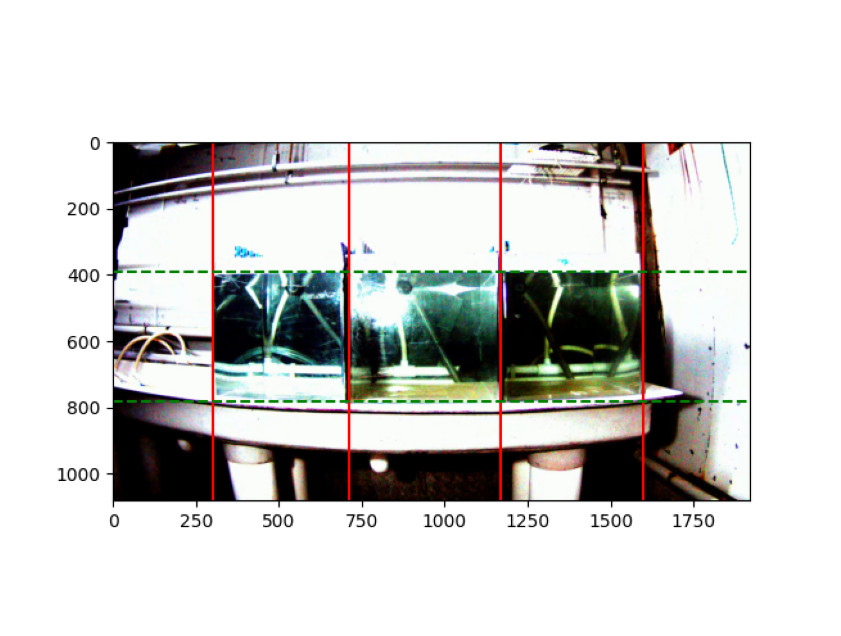

In [6]:
import subprocess
import matplotlib.pyplot as plt
import cv2
import os

# Parameters
video_path = '/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part1.mp4'
frame_number = 500
x_lines = [300, 710, 1170, 1600]
y_lines = [390, 780]
output_image = '../../results/041325PA_experimental.png'  # Save to results folder

# Build command
cmd = [
    'python3', '../../scripts/visualize_tanx.py',
    '-v', video_path,
    '-f', str(frame_number),
    '-t', *map(str, x_lines),
    '-y', *map(str, y_lines),
    '-o', output_image
]

# Run the script
subprocess.run(cmd, check=True)

# Display the image in the notebook
if os.path.exists(output_image):
    img = cv2.imread(output_image)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    print('Visualization image not found.')

In [10]:
# "black frame" is defined by ffmpeg’s blackdetect filter with these parameters:
#
#d=0.5: The minimum duration (in seconds) for a black segment to be detected.
#pix_th=0.10: The pixel threshold; a frame is considered "black" if at least 90% of its pixels have a luma (brightness) value below the default threshold (default is 32 out of 255).
#So, a black frame is one where at least 90% of its pixels are very dark (luma < 32), and a black segment is reported if this condition lasts for at least 0.5 seconds.


import subprocess
import cv2
import re
import pandas as pd

video_path = video_path = '/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part4.mp4'
# ffmpeg blackdetect
cmd = (
    f'ffmpeg -hide_banner -nostats -i "{video_path}" '
    '-vf "blackdetect=d=0.5:pix_th=0.10" -an -f null - 2>&1 | grep "black_start" | tail -1'
)
result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
line = result.stdout.strip()
print("ffmpeg output:", line)  # Debug print

# Extract blackdetect times
match = re.search(r'black_start:(\d+\.\d+)\s+black_end:(\d+\.\d+)\s+black_duration:(\d+\.?\d*)', line)
if match:
    black_start = float(match.group(1))
    black_end = float(match.group(2))
    black_duration = float(match.group(3))
else:
    black_start = black_end = black_duration = None

# OpenCV video info
cap = cv2.VideoCapture(video_path)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()
total_length = frame_count / fps if fps else None

def sec_to_mmss(seconds):
    if seconds is None:
        return ""
    m, s = divmod(int(seconds), 60)
    return f"{m:02d}:{s:02d}"

def sec_to_frame(seconds, fps):
    if seconds is None or not fps:
        return ""
    return int(round(seconds * fps))

table = [
    {"event": "total_length", "frame": frame_count, "time (mm:ss)": sec_to_mmss(total_length)},
    {"event": "blackstart", "frame": sec_to_frame(black_start, fps), "time (mm:ss)": sec_to_mmss(black_start)},
    {"event": "blackend", "frame": sec_to_frame(black_end, fps), "time (mm:ss)": sec_to_mmss(black_end)},
    {"event": "blackduration", "frame": sec_to_frame(black_duration, fps), "time (mm:ss)": sec_to_mmss(black_duration)},
]

darkness = pd.DataFrame(table)
print(darkness)

ffmpeg output: [blackdetect @ 0x7f60f8003b80] black_start:197.8 black_end:2586.8 black_duration:2389
           event  frame time (mm:ss)
0   total_length  25869        43:06
1     blackstart   1978        03:17
2       blackend  25868        43:06
3  blackduration  23890        39:49


In [12]:
# Import required functions from the script
import sys
sys.path.append('../../scripts')  # Adjust path if needed
from find_contours import find_contours_from_videos


# Set parameters for contour finding
video_pattern = '/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part??.mp4'
output_file = '041325PA_control.tab'
black = 110
minArea = 1.5
maxArea = 1000.0
brightnessThreshold = 50
threads = 4
maxy = None

# Run contour finding and write results to file
xlim = [300, 1600]
ylim = [390, 780]

results = find_contours_from_videos(
    video_pattern=video_pattern,
    black=black,
    minArea=minArea,
    maxArea=maxArea,
    brightnessThreshold=brightnessThreshold,
    threads=threads,
    outfile=output_file,
    maxy=maxy,
    xlim=xlim,
    ylim=ylim
)
print(f'Contour results written to {output_file}')

Processing videos:   0%|          | 0/24 [00:00<?, ?it/s]

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_p…

Processed 500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part04.mp4
Processed 1000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part04.mp4
Processed 1500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part04.mp4
Processed 2000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part04.mp4
Processed 2500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part04.mp4
Processed 3000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part04.mp4
Processed 3500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experiment

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_p…

Processed 500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part05.mp4
Processed 1000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part05.mp4
Processed 1500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part05.mp4
Processed 2000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part05.mp4
Processed 2500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part05.mp4
Processed 3000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part05.mp4
Processed 3500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experiment

...

Processed 500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part24.mp4
Processed 1000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part24.mp4
Processed 1500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part24.mp4
Processed 2000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part24.mp4
Processed 2500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part24.mp4
Processed 3000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part24.mp4
Processed 3500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experiment

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_p…

Processed 500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part25.mp4
Processed 1000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part25.mp4
Processed 1500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part25.mp4
Processed 2000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part25.mp4
Processed 2500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part25.mp4
Processed 3000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part25.mp4
Processed 3500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experiment

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_p…

Processed 500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part26.mp4
Processed 1000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part26.mp4
Processed 1500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part26.mp4
Processed 2000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part26.mp4
Processed 2500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part26.mp4
Processed 3000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experimental_part26.mp4
Processed 3500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/13Apr25/041325PA_experimental/041325PA_experiment

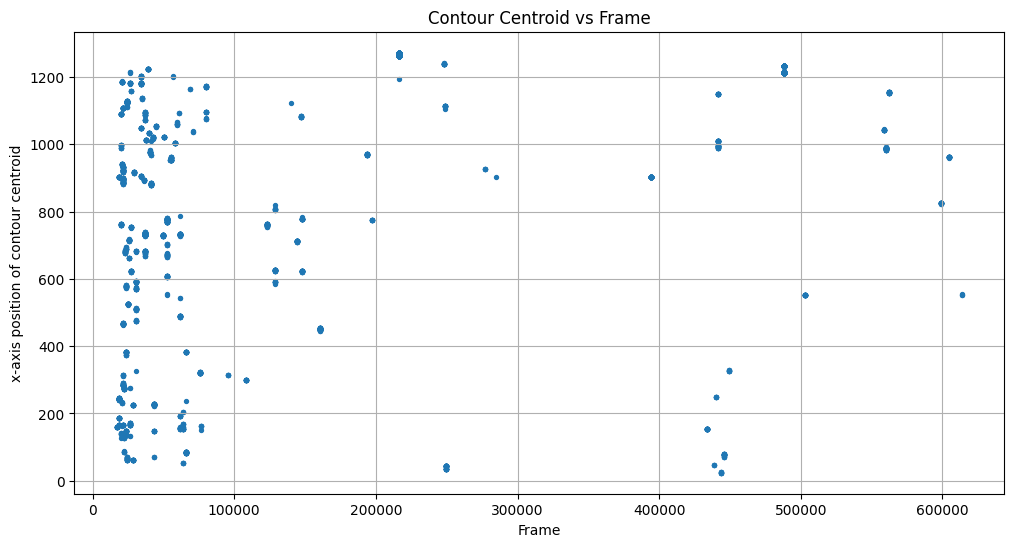

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the tab-separated file
df = pd.read_csv('contours_041325PA_control.tab', sep='\t')

# Plot frame vs cX
plt.figure(figsize=(12, 6))
plt.scatter(df['frame'], df['cX'], s=8)
plt.xlabel('Frame')
plt.ylabel('x-axis position of contour centroid')
plt.title('Contour Centroid vs Frame')
plt.grid(True)
plt.show()